In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from catboost import CatBoostRegressor
import joblib

In [22]:
df = pd.read_csv('../data/train.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## Разведочный анализ данных (EDA)

Смотрим на структуру данных: типы колонок, пропуски, распределение целевой переменной `count`.

!колонки `casual` и `registered` в сумме дают `count` (casual + registered = count)!
Это утечка данных — использовать их как признаки нельзя, в тестовых данных их нет.
Эти колонки исключаем из набора признаков.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [24]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


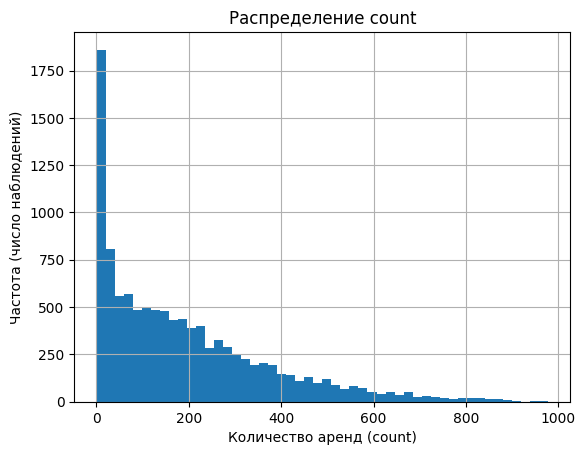

In [25]:
df['count'].hist(bins=50)
plt.title('Распределение count')
plt.xlabel('Количество аренд (count)')
plt.ylabel('Частота (число наблюдений)')
plt.show()

### Выводы по EDA

- Пропусков в данных нет (10886 строк, везде non-null).
- `datetime` хранится как строка — нужно распарсить в дату/время.
- Целевая переменная `count` имеет скошенное вправо распределение
  (много маленьких значений, редкие большие пики) — типично для данных
  спроса. Применим логарифмирование `log(count + 1)` на шаге обучения,
  чтобы модели было проще уловить закономерность.

In [26]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month

features = ['season', 'holiday', 'workingday', 'weather',
            'temp', 'humidity', 'windspeed', 'hour', 'dayofweek', 'month']
X = df[features]
y = np.log1p(df['count'])  # log(count + 1) — логарифмирование, чтобы работал с размыми данными

## Разбиение на train/test и обучение модели

Используем CatBoostRegressor — градиентный бустинг над деревьями решений.
В отличие от RandomForest, деревья строятся
последовательно: каждое следующее дерево исправляет ошибки предыдущих.
Обычно даёт более точный результат на табличных данных.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = CatBoostRegressor(
    iterations=500,        # количество деревьев (аналог n_estimators)
    learning_rate=0.05,    # скорость обучения — насколько сильно каждое новое дерево корректирует ошибку
    depth=6,                # глубина каждого дерева
    random_state=42,        # фиксирует случайность
    verbose=100              # раз в сколько итераций печатать прогресс обучения
)
model.fit(X_train, y_train)

0:	learn: 1.3638935	total: 144ms	remaining: 1m 11s
100:	learn: 0.4201669	total: 300ms	remaining: 1.18s
200:	learn: 0.3638188	total: 474ms	remaining: 704ms
300:	learn: 0.3408222	total: 633ms	remaining: 419ms
400:	learn: 0.3250020	total: 804ms	remaining: 199ms
499:	learn: 0.3128139	total: 964ms	remaining: 0us


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=100)

In [28]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values(ascending=False)

hour          68.666951
workingday     8.432490
dayofweek      6.124382
temp           5.174582
month          3.809549
humidity       3.160872
season         1.891429
weather        1.816896
windspeed      0.807460
holiday        0.115389
dtype: float64

In [29]:
preds_log = model.predict(X_test)

# переводим обратно из логарифма в реальные числа аренд
preds = np.expm1(preds_log)
y_test_real = np.expm1(y_test)

rmse = root_mean_squared_error(y_test_real, preds)
r2 = r2_score(y_test_real, preds)

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.4f}')

RMSE: 65.39
R2: 0.8705


## Сравнение с RandomForest (не присутствует в этом проекте)

CatBoostRegressor показал улучшение по сравнению с базовой моделью:

| Модель        | RMSE  | R²    |
|---------------|-------|-------|
| RandomForest  | 74.93 | 0.8299|
| CatBoost      | 65.39 | 0.8705|

Градиентный бустинг (последовательное исправление ошибок) оказался
эффективнее ансамбля независимых деревьев для этой задачи.

In [30]:
joblib.dump(model, '../models/model.pkl')

['../models/model.pkl']